In [1]:
import sys

import hyperspy.api as hs
import matplotlib.pyplot as plt
import numpy as np

sys.path.append('..')
import roi_tools


In [2]:
s_original = hs.load('../data/images/Jaume LFO/HAADF_Buena.dm3')

left_bound = 20
right_bound = 2048 - 20
start_pixel = 200
end_pixel = 2048 - 100

s = s_original.isig[left_bound:right_bound, start_pixel:end_pixel]


In [3]:
grid_creator = roi_tools.GridCreator()
layout = grid_creator.detect_layout(s)
grid = grid_creator.process(s, layout=layout)
grid = roi_tools.equalize_patch_sizes(grid)

position_analyzer = roi_tools.PositionAnalyzer(maxfev=1000)
positions = position_analyzer.fit(grid)


/Users/wujn/Documents/Projects Codes/h-LFO-point-defects/notebooks/../roi_tools/roi.py:315: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


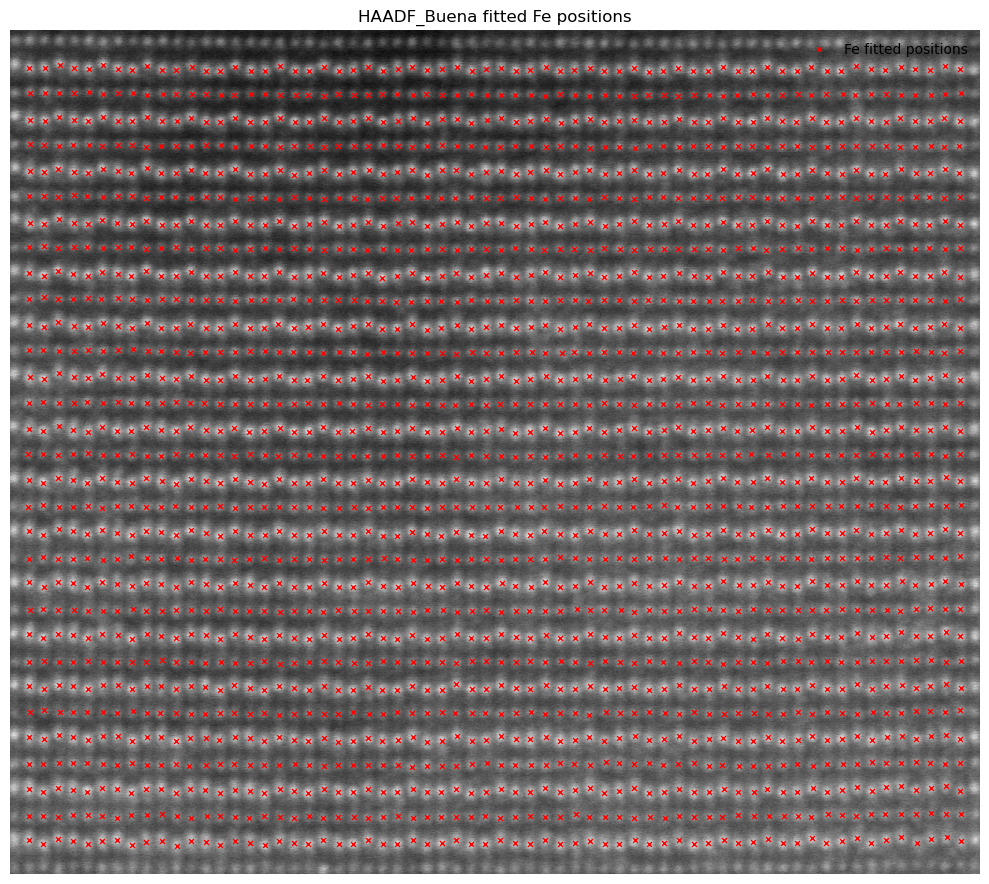

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
plotter = roi_tools.PatchGridPlotter(s, grid, ax=ax)

artist = plotter.add_positions(
    positions,
    atom_type='all',
    size=12,
    color='red',
    marker='x',
    linewidths=1.0,
    label='Fe fitted positions',
    zorder=5,
)

ax.set_title('HAADF_Buena fitted Fe positions')
ax.axis('off')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
plt.show()
